In [1]:
from collections import defaultdict

import jax

import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np

# Setup

We train a linear model and observe the training dynamics wrt the learning rate η for fixed -
 
- batch size $B$ or 
- *temperature* given by $\frac{\eta}{B}$.


In [2]:
from batch_size_studies.configs import get_main_experiment_configs, get_main_hyperparameter_grids
from batch_size_studies.data_utils import (
    filter_loss_dicts,
    moving_average,
    sample_aware_smooth_loss_dicts,
    extract_loss_histories,
    filter_loss_dict_by_cutoff,
    subsample_loss_dict_periodic,
    filter_experiments,
)

from batch_size_studies.definitions import RunKey, LossType, OptimizerType
from batch_size_studies.experiments import (
    Parameterization,
    SyntheticExperimentFixedData,
    SyntheticExperimentFixedTime,
    MNIST1MExperiment,
    MNIST1MSampledExperiment,
)
from batch_size_studies.plotting_utils import plot_loss_curves, plot_loss_heatmap, plot_all_loss_curves
from batch_size_studies.runner import run_experiment_sweep

In [3]:
MOVING_AVG_SAMPLES_WINDOW = 100

rk_smoother = lambda rk, loss_history: moving_average(
    loss_history, max(round(MOVING_AVG_SAMPLES_WINDOW / rk.batch_size), 1)
)

In [4]:
batch_sizes = (2 ** np.arange(0, 10)).tolist()
etas = np.power(2.0, np.linspace(-4, 2, 21)).tolist()


print(f"There are {len(batch_sizes)} batch sizes:")
print(batch_sizes)

print(f"\n There are {len(etas)} learning rates:")
print([f"{eta:.2e}" for eta in etas])

There are 10 batch sizes:
[1, 2, 4, 8, 16, 32, 64, 128, 256, 512]

 There are 21 learning rates:
['6.25e-02', '7.69e-02', '9.47e-02', '1.17e-01', '1.44e-01', '1.77e-01', '2.18e-01', '2.68e-01', '3.30e-01', '4.06e-01', '5.00e-01', '6.16e-01', '7.58e-01', '9.33e-01', '1.15e+00', '1.41e+00', '1.74e+00', '2.14e+00', '2.64e+00', '3.25e+00', '4.00e+00']


In [5]:
all_temps = np.unique(np.array(etas)[:, np.newaxis] / np.array(batch_sizes))
print(
    f"Temperatures are in the range [2^{round(np.log2(all_temps).min())}, 2^{round(np.log2(all_temps).max())}], logarithmically spaced."
)

Temperatures are in the range [2^-13, 2^2], logarithmically spaced.


# Linear Model

In [6]:
from batch_size_studies.experiments import SyntheticExperimentLinearTeacher

In [7]:
all_experiments = get_main_experiment_configs()
batch_sizes, etas = get_main_hyperparameter_grids()

print(f"There are {len(batch_sizes)} batch sizes:")
print(batch_sizes)

print(f"\n There are {len(etas)} learning rates:")
print([f"{eta:.0e}" for eta in etas])

There are 17 batch sizes:
[1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536]

 There are 26 learning rates:
['2e-04', '5e-04', '1e-03', '2e-03', '4e-03', '8e-03', '2e-02', '3e-02', '6e-02', '1e-01', '2e-01', '5e-01', '1e+00', '2e+00', '4e+00', '8e+00', '2e+01', '3e+01', '6e+01', '1e+02', '3e+02', '5e+02', '1e+03', '2e+03', '4e+03', '8e+03']


In [8]:
EXPERIMENT_TYPE = SyntheticExperimentLinearTeacher


OPTIMIZER = OptimizerType.SGD
LOSS_TYPE = LossType.MSE

In [9]:
experiments = filter_experiments(all_experiments, EXPERIMENT_TYPE, loss_type=LOSS_TYPE, optimizer=OPTIMIZER)
for k in experiments.keys():
    print(k)

linear_teacher_P1048576_epochs1
noisy_linear_teacher_P1048576_epochs1_rho0p25
noisy_linear_teacher_P1048576_epochs1_rho0p6
linear_teacher_P131072_epochs8
noisy_linear_teacher_P131072_epochs8_rho0p25
noisy_linear_teacher_P131072_epochs8_rho0p6
linear_teacher_P1024_epochs1024
noisy_linear_teacher_P1024_epochs1024_rho0p25
noisy_linear_teacher_P1024_epochs1024_rho0p6


The names of the experiments should follow the convention:

 `<task>_<parameterization>_<loss_fn_type>_<optimizer>_<gamma_value>`


Each experiment object is a Dataclass with all relevant parameters for training dynamics specified. Let's look at one.

In [10]:
import random

random.choice(list(experiments.values())).describe()

SyntheticExperimentLinearTeacher(optimizer=<OptimizerType.SGD: 'SGD'>,
                                 loss_type=<LossType.MSE: 'MSE'>,
                                 experiment_type='fixed_data_linear_teacher',
                                 D=500,
                                 P=1048576,
                                 alpha=2.0,
                                 beta=0.25,
                                 num_epochs=1,
                                 seed=0)


In [11]:
loss_dicts = defaultdict(list)

In [23]:
import logging

logging.getLogger().setLevel(logging.INFO)  # this gives more descriptive logs when runs are skipped

for exp_name, e in experiments.items():
    results_obj, fails = run_experiment_sweep(
        e, batch_sizes, etas
    )  # second is failed_runs, which is the set of RunKeys (batch, eta) that have diverged in prior experiments ran
    loss_dicts[exp_name] = results_obj

INFO:root:All requested (B, η) combinations already complete. Skipping sweep.
INFO:root:All requested (B, η) combinations already complete. Skipping sweep.
INFO:root:All requested (B, η) combinations already complete. Skipping sweep.
INFO:root:All requested (B, η) combinations already complete. Skipping sweep.
INFO:root:All requested (B, η) combinations already complete. Skipping sweep.
INFO:root:All requested (B, η) combinations already complete. Skipping sweep.
INFO:root:All requested (B, η) combinations already complete. Skipping sweep.
INFO:root:All requested (B, η) combinations already complete. Skipping sweep.
INFO:root:All requested (B, η) combinations already complete. Skipping sweep.


The `results_obj` object, loaded from an experiment's results file, is a Python dictionary that maps each hyperparameter trial to its outcome.

*   **Keys**: The keys of the dictionary are `RunKey` objects. A `RunKey` is a lightweight object that uniquely identifies a single training run by its core hyperparameters, which are `batch_size` and `eta` (learning rate).
    *   *Example*: `RunKey(batch_size=64, eta=0.01)`

*   **Values**: The values are dictionaries containing the metrics for that specific run. Common keys in this inner dictionary include:
    *   `'loss_history'`: A list of loss values recorded during training.
    *   `'epoch_test_accuracies'`: A list of test accuracies, one for each epoch.
    *   `'final_test_accuracy'`: The final test accuracy achieved by the run.

In next iteration of the work, we would replace `eta` with object fully specifying the behavior of the appropriate optimizer (say, betas for Adam).

## Online losses in batches and in temp

To treat runs wtih different batch sizes (and hence less iterations) together, we smooth the loss curve in sample space, i.e. the window of the moving average depends on the batch size

In [13]:
from batch_size_studies.data_utils import filter_loss_dict_by_loss_threshold, adjust_run_keys_in_dict

Note that in our code the loss for a batch $\mathcal{B}$ of size $B$ is computed via
$$ 
L(\mathcal{B}) = 1/B \sum_{i \in \mathcal{B}} l(i)
$$
while the theory assumes $L \approx \frac12 \mathbb{E}[L]$, so to match the theory precisely we must divide $\eta \to \frac{\eta}{2}$


In [14]:
# divide_eta_by_two = lambda rk: RunKey(rk.batch_size, rk.eta/2)
# loss_dict = adjust_run_keys_in_dict(loss_dict, divide_eta_by_two)

In [15]:
from batch_size_studies.plotting_utils import plot_heatmap_with_theory_curve

In [16]:
lambda_max_val = 1
tr_sigma_val = np.sum(np.arange(1, 501) ** -1.1)

In [17]:
lower_bound = lambda b: 2 / (lambda_max_val * (1 + 1 / b) + tr_sigma_val / b)

In [18]:
crit_batch = tr_sigma_val / lambda_max_val

In [19]:
from batch_size_studies.plotting_utils import _default_final_metric_extractor, _final_validation_error_extractor

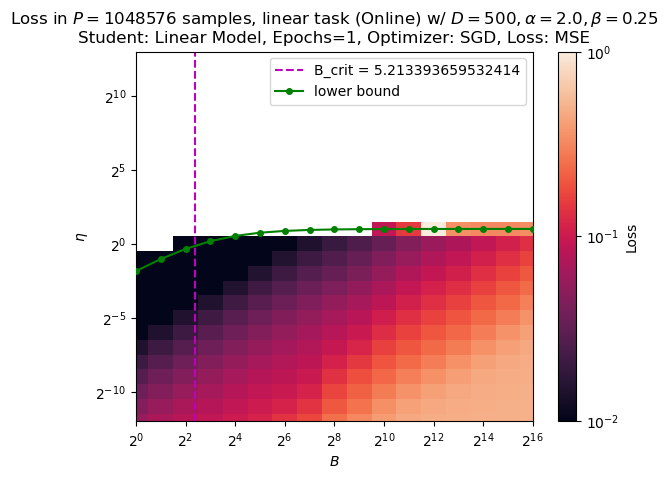

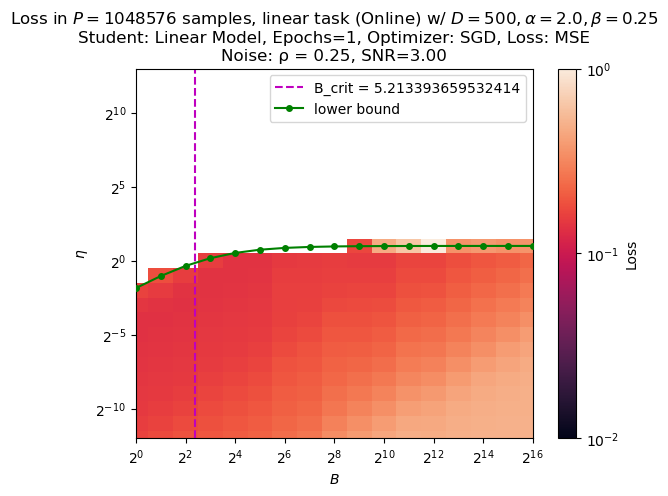

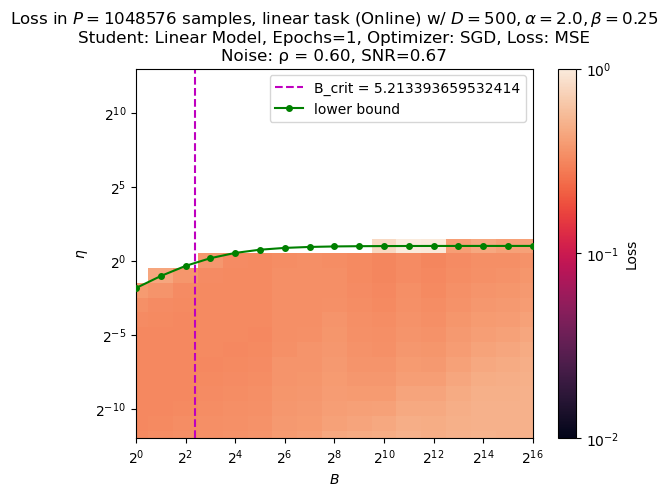

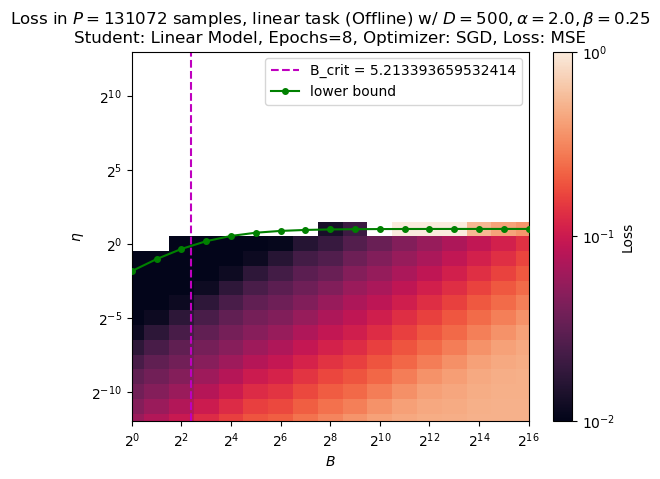

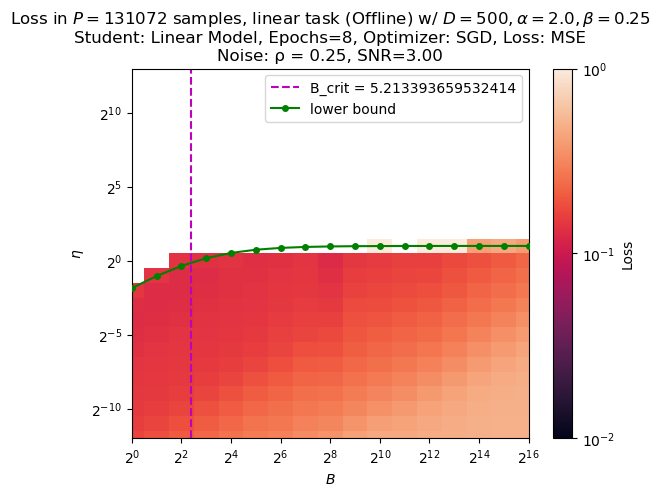

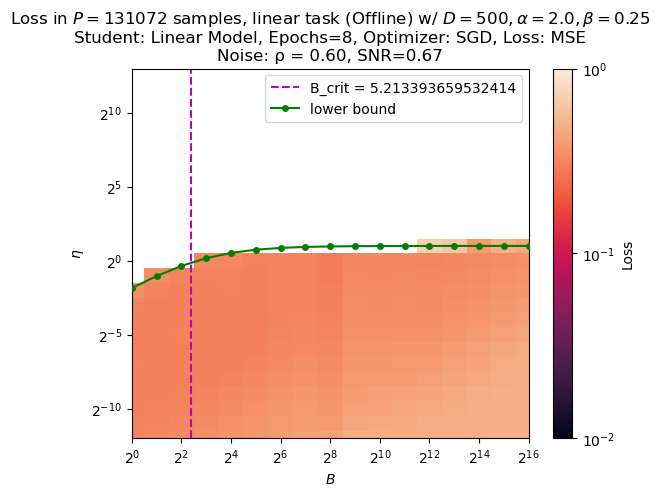

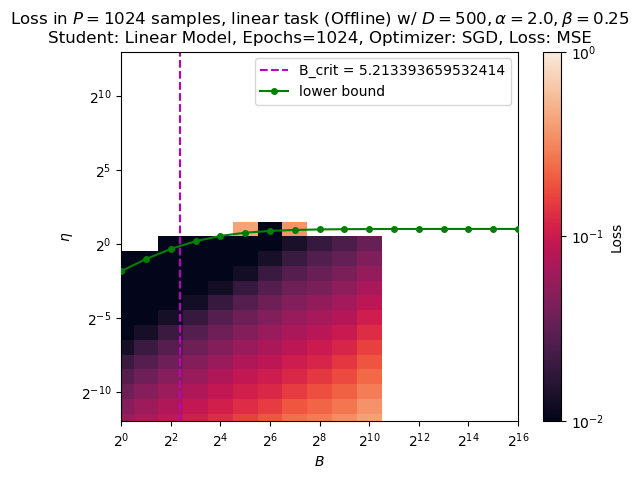

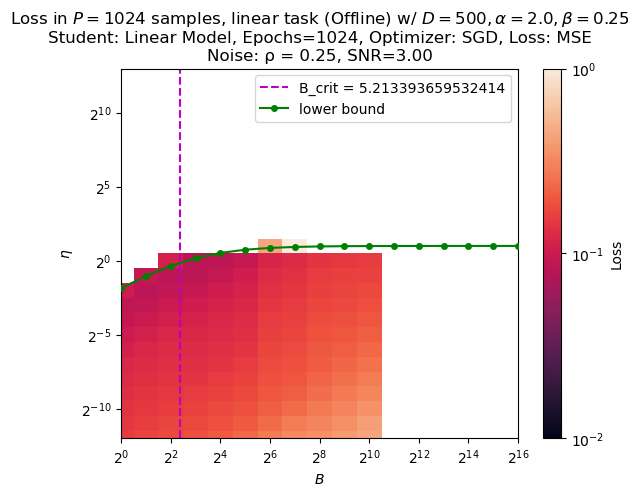

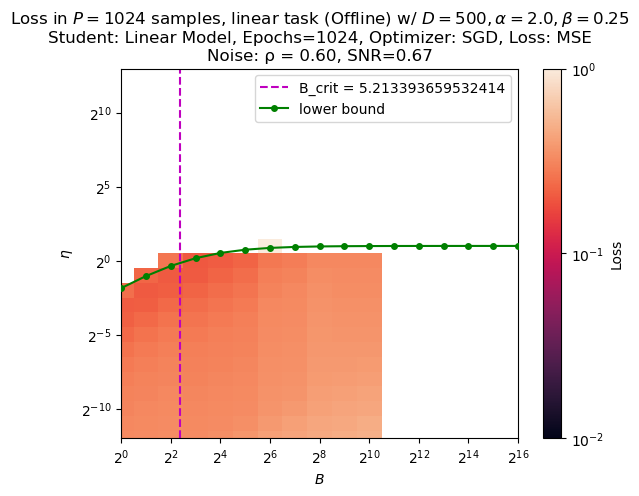

In [20]:
for e_name, experiment in experiments.items():
    loss_dict = loss_dicts[e_name]
    loss_dict = filter_loss_dict_by_loss_threshold(loss_dict, 100)
    plot_heatmap_with_theory_curve(
        sample_aware_smooth_loss_dicts(loss_dict, rk_smoother),
        # loss_dict,
        batch_sizes,
        etas,
        experiment.plot_title(),
        # first_divergence=first_divergence,
        lower_bound=lower_bound,
        # upper_bound=upper_bound,
        crit_batch=crit_batch,
        clim=(-2, 0),
    )

In [21]:
assert False

AssertionError: 

In [ ]:
from batch_size_studies.checkpoint_utils import load_final_weights_for_experiment

experiment_cfg = experiments["linear_teacher_P1024_epochs1024"]
final_weights = load_final_weights_for_experiment(
    experiment_cfg,
    directory="/Users/stanislav/Desktop/coding/Pehlevan lab recover/batch_size_studies/experiments",
)

In [ ]:
test_error_fn = experiment_cfg.get_test_error_fn()

In [ ]:
def _metric_extractor(result) -> float | None:
    """Default metric_extractor for heatmaps, gets the last loss value."""
    return result

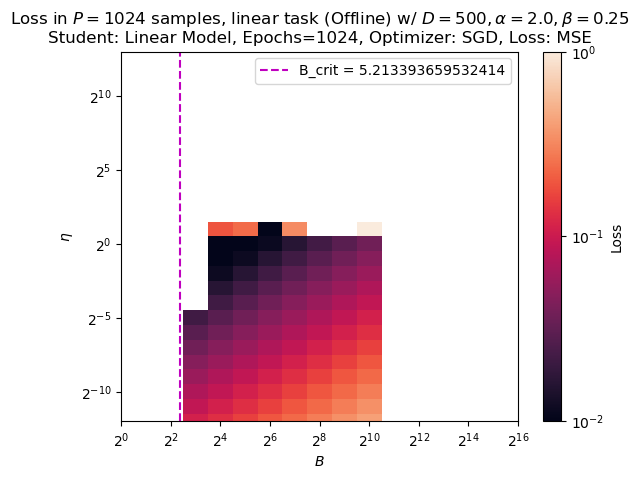

In [ ]:
plot_heatmap_with_theory_curve(
    values,
    batch_sizes,
    etas,
    experiment_cfg.plot_title(),
    metric_extractor=_metric_extractor,
    # first_divergence=first_divergence,
    # lower_bound=lower_bound,
    # upper_bound=upper_bound,
    crit_batch=crit_batch,
    clim=(-2, 0),
);

In [ ]:
final_weights

{RunKey(batch_size=8, eta=0.03125): Array([[ 6.16638482e-01],
        [ 7.44316339e-01],
        [ 8.43220115e-01],
        [ 8.76123428e-01],
        [ 9.18148279e-01],
        [ 1.08220136e+00],
        [ 9.81214702e-01],
        [ 1.04593170e+00],
        [ 1.04887497e+00],
        [ 1.16195917e+00],
        [ 1.13813031e+00],
        [ 1.19279158e+00],
        [ 1.24572098e+00],
        [ 1.18912494e+00],
        [ 1.29115868e+00],
        [ 1.21635282e+00],
        [ 1.42165625e+00],
        [ 1.28434193e+00],
        [ 1.26040220e+00],
        [ 1.36366308e+00],
        [ 1.20347393e+00],
        [ 1.36308038e+00],
        [ 1.12179816e+00],
        [ 1.33089590e+00],
        [ 1.33022237e+00],
        [ 1.47486746e+00],
        [ 1.39403629e+00],
        [ 8.99024785e-01],
        [ 1.33436239e+00],
        [ 1.54390502e+00],
        [ 1.29775631e+00],
        [ 1.42471755e+00],
        [ 1.45493948e+00],
        [ 1.11707032e+00],
        [ 2.01100636e+00],
        [ 1.33182573

In [ ]:
from batch_size_studies.checkpoint_utils import CheckpointManager

In [ ]:
manager = CheckpointManager(experiment_cfg).weights_filepath

In [ ]:
manager.weights_filepath

'experiments/fixed_data_linear_teacher/_D=500_P=1024_alpha=2p0_beta=0p25_loss_type=MSE_num_epochs=1024_optimizer=SGD_seed=0_weights.pkl'

In [ ]:
import pickle
from batch_size_studies.checkpoint_utils import CheckpointManager

mgr = CheckpointManager(experiment_cfg)
with open(mgr.weights_filepath, "rb") as f:
    data = pickle.load(f)

print(data.keys())  # should show initial_params, weight_snapshots, metadata
print(len(data.get("weight_snapshots", {})))

FileNotFoundError: [Errno 2] No such file or directory: 'experiments/fixed_data_linear_teacher/_D=500_P=1024_alpha=2p0_beta=0p25_loss_type=MSE_num_epochs=1024_optimizer=SGD_seed=0_weights.pkl'

In [ ]:
import pickle

In [ ]:
file = pickle.load(open(manager.weights_filepath))

FileNotFoundError: [Errno 2] No such file or directory: 'experiments/fixed_data_linear_teacher/_D=500_P=1024_alpha=2p0_beta=0p25_loss_type=MSE_num_epochs=1024_optimizer=SGD_seed=0_weights.pkl'

In [ ]:
experiment_cfg

SyntheticExperimentLinearTeacher(optimizer=<OptimizerType.SGD: 'SGD'>, loss_type=<LossType.MSE: 'MSE'>, experiment_type='fixed_data_linear_teacher', D=500, P=1024, alpha=2.0, beta=0.25, num_epochs=1024, seed=0)

In [ ]:
final_weights

{}

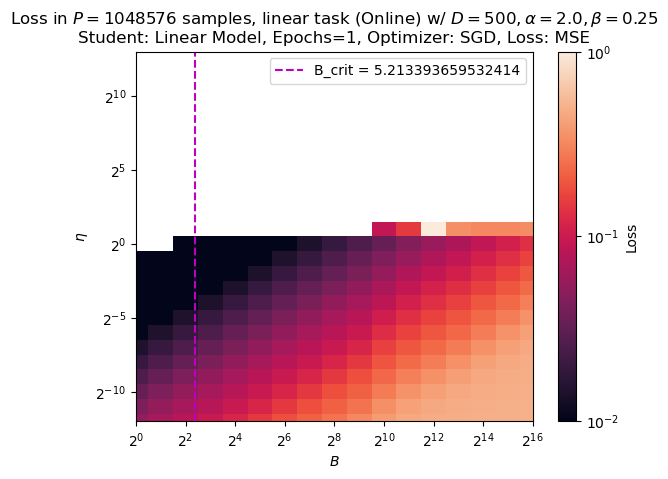

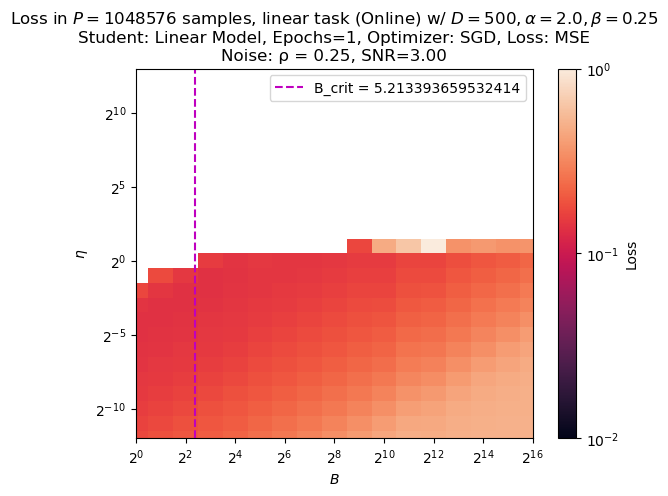

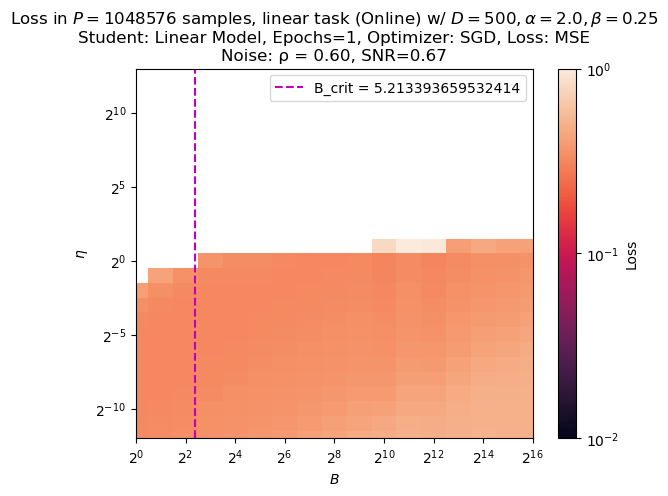

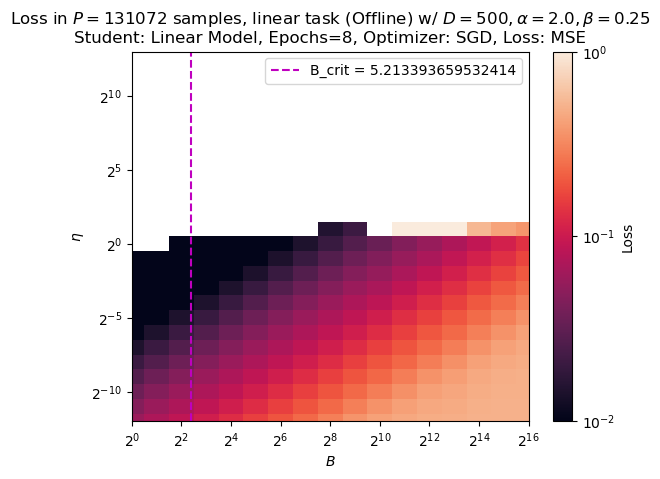

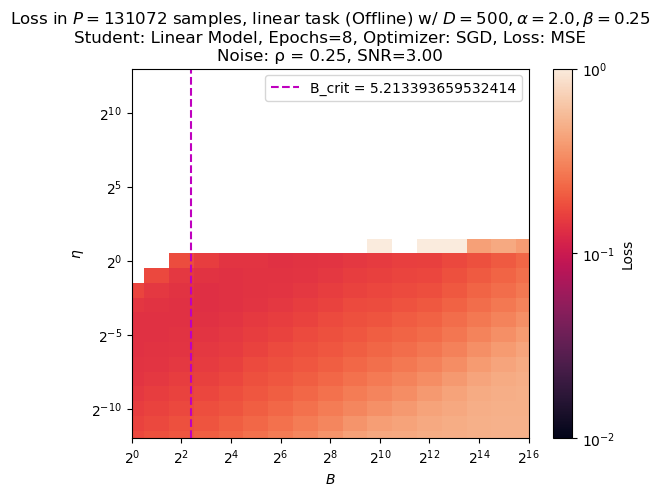

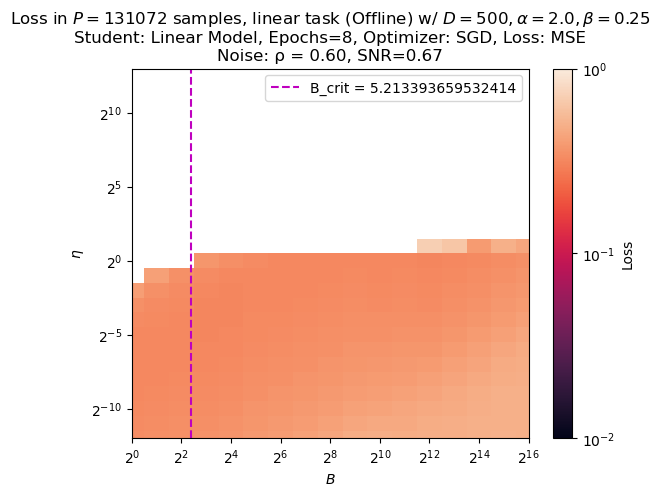

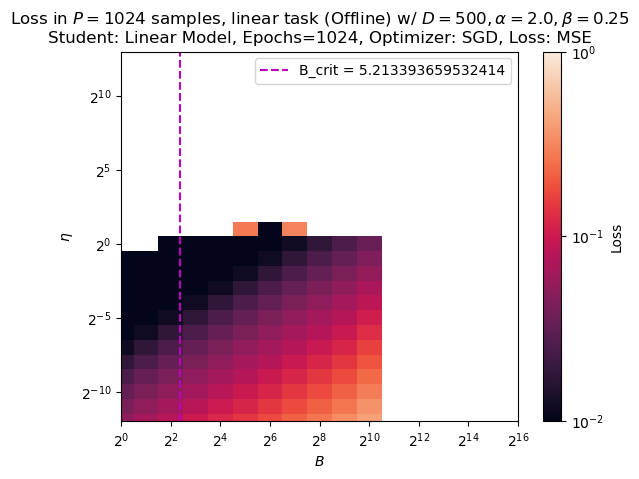

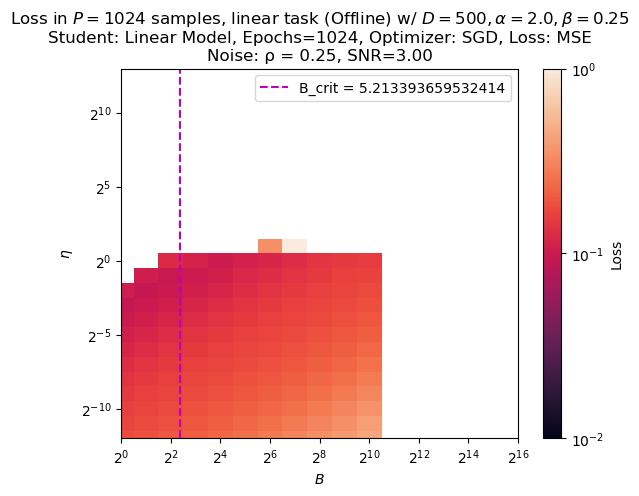

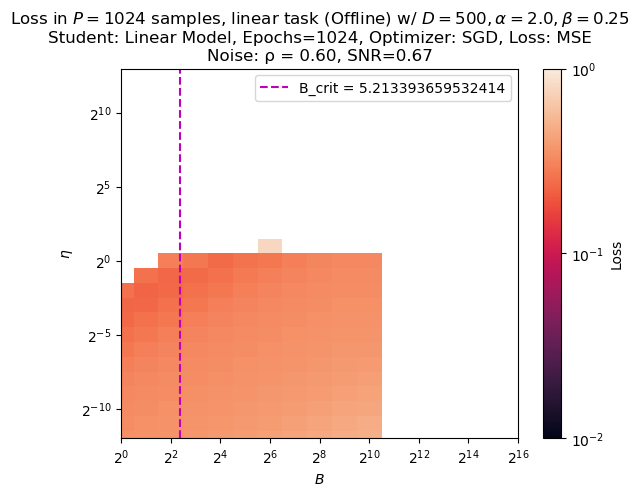

In [ ]:
for e_name, experiment in experiments.items():
    loss_dict = loss_dicts[e_name]
    loss_dict = filter_loss_dict_by_loss_threshold(loss_dict, 100)
    plot_heatmap_with_theory_curve(
        sample_aware_smooth_loss_dicts(loss_dict, rk_smoother),
        #    loss_dict,
        batch_sizes,
        etas,
        experiment.plot_title(),
        # first_divergence=first_divergence,
        # lower_bound=lower_bound,
        # upper_bound=upper_bound,
        crit_batch=crit_batch,
        clim=(-2, 0),
    )

In [ ]:
assert False

In [ ]:
e_name = "online_linear_teacher_alpha2p0_beta0p25_long"
experiment = experiments[e_name]

loss_dict = loss_dicts[e_name]

In [ ]:
loss_dict = filter_loss_dict_by_loss_threshold(loss_dict, 100)

In [ ]:
crit_batch = tr_sigma_val / (lambda_max / 2)

In [ ]:
from batch_size_studies.hessian_evaluator import HessianEvaluator

evaluator = HessianEvaluator(
    experiment=experiment,
    run_key=None,  # stay at initialization
    step=None,
    # directory="experiments", # or your custom sweep directory
    num_hessian_samples=1024,
    hessian_batch_size=128,
)

eigvals, eigvecs = evaluator.top_eigenvalues(top_n=1)
lambda_max = eigvals[0]
trace_val = evaluator.trace(max_iter=100)

In [ ]:
eigvals, eigvecs = evaluator.top_eigenvalues(top_n=1)
lambda_max = eigvals[0]

In [ ]:
trace_val = evaluator.trace(max_iter=100)

In [ ]:
lambda_max / 2

Array(0.965172, dtype=float32)

In [ ]:
lambda_max_val

1

In [ ]:
crit_batch = tr_sigma_val / (lambda_max / 2)

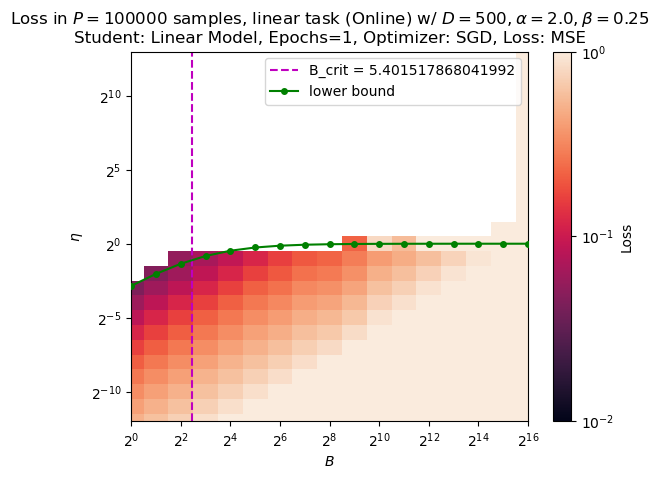

In [ ]:
plot_heatmap_with_theory_curve(
    sample_aware_smooth_loss_dicts(loss_dict, rk_smoother),
    # loss_dict,
    batch_sizes,
    etas,
    experiment.plot_title(),
    # first_divergence=first_divergence,
    lower_bound=lower_bound,
    # upper_bound=upper_bound,
    crit_batch=crit_batch,
    clim=(-2, 0),
);

(<Figure size 3010x800 with 1 Axes>,
 <Axes: title={'center': 'Loss Curves\n$P = 100000$ samples, linear task (Online) w/ $D=500, \\alpha=2.0, \\beta=0.25$\nStudent: Linear Model, Epochs=1, Optimizer: SGD, Loss: MSE'}, xlabel='Effective Steps (steps * η)', ylabel='Loss'>)

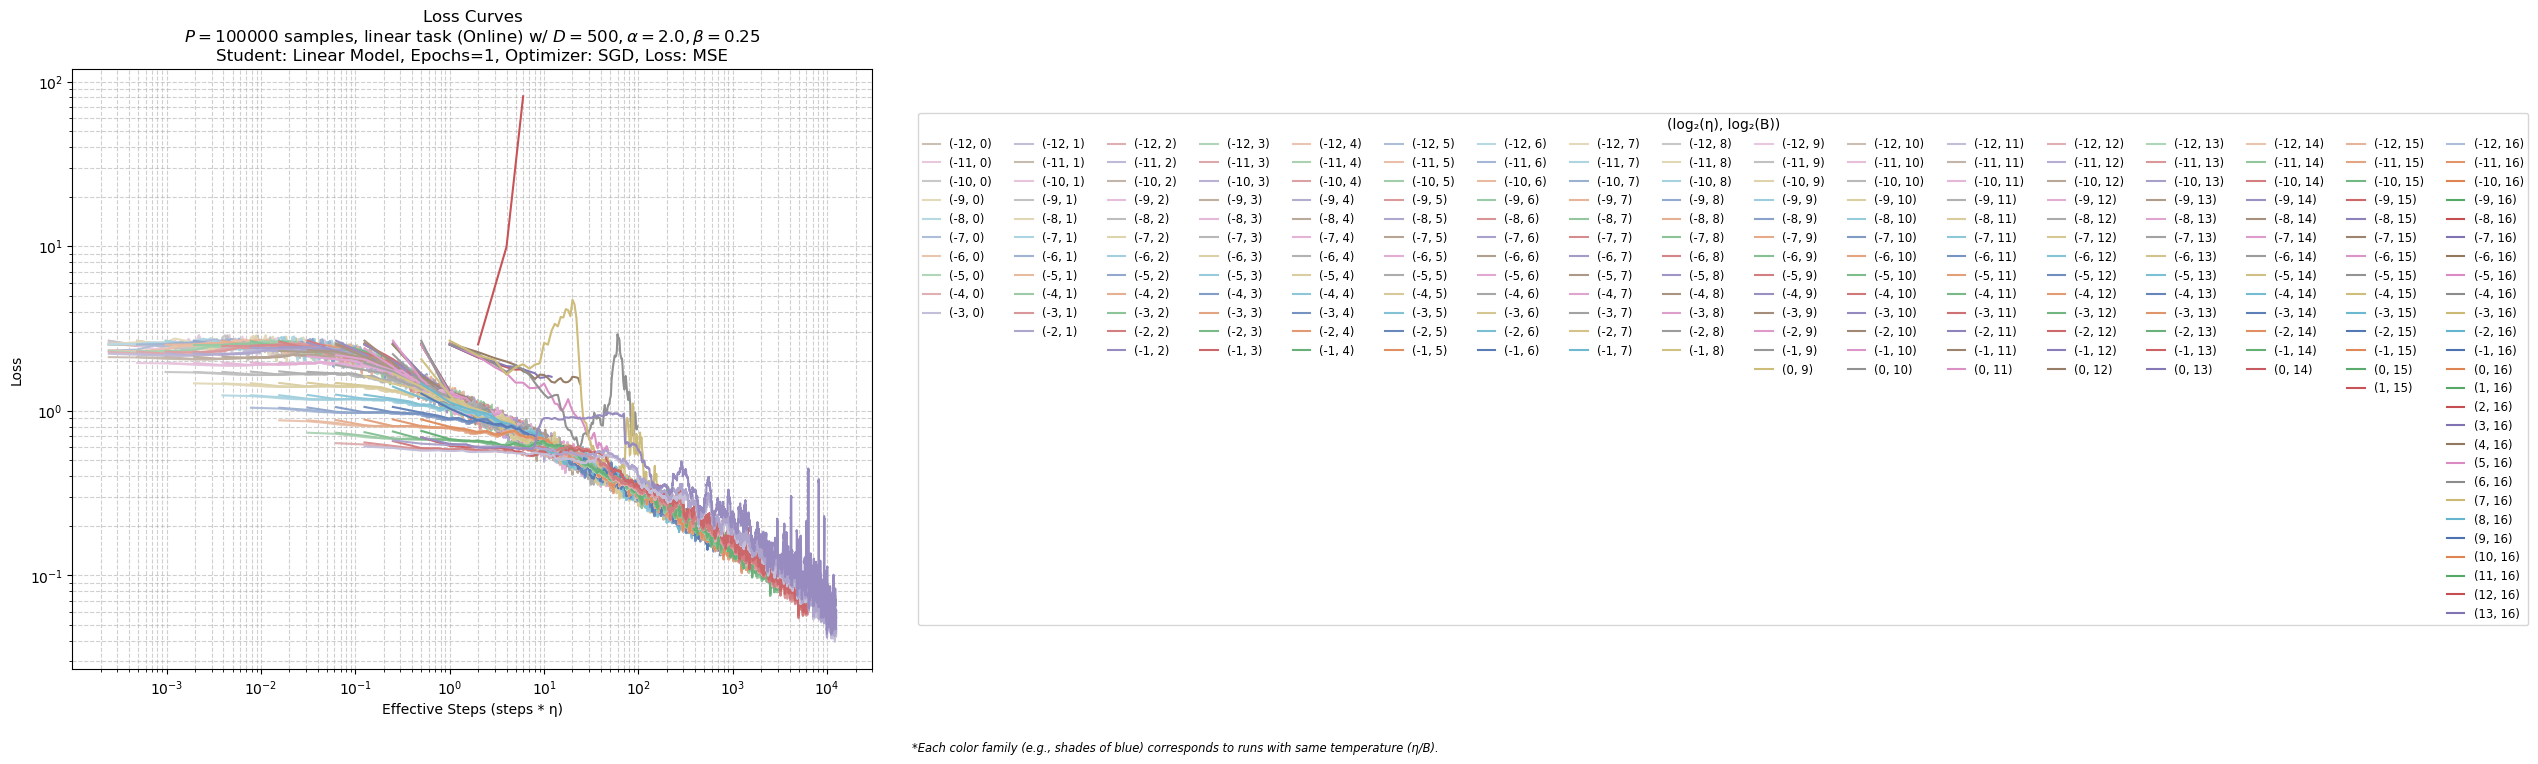

In [ ]:
plot_all_loss_curves(
    sample_aware_smooth_loss_dicts(loss_dict, rk_smoother),
    title_exp=experiment.plot_title(),
    use_eff_steps=True,
    x_scale="log",
)

In [ ]:
e_name = "offline_linear_teacher_alpha2p0_beta0p25_long"
experiment = experiments[e_name]

loss_dict = loss_dicts[e_name]

In [ ]:
loss_dict = filter_loss_dict_by_loss_threshold(loss_dict, 100)

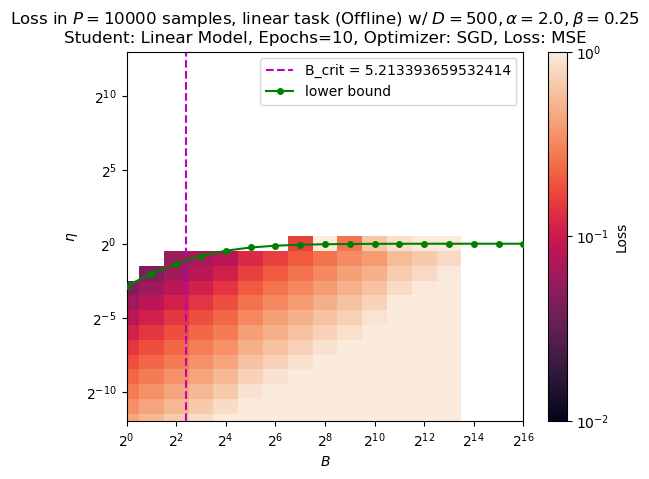

In [ ]:
plot_heatmap_with_theory_curve(
    sample_aware_smooth_loss_dicts(loss_dict, rk_smoother),
    # loss_dict,
    batch_sizes,
    etas,
    experiment.plot_title(),
    # first_divergence=first_divergence,
    lower_bound=lower_bound,
    # upper_bound=upper_bound,
    crit_batch=crit_batch,
    clim=(-2, 0),
);

(<Figure size 2530x800 with 1 Axes>,
 <Axes: title={'center': 'Loss Curves\n$P = 10000$ samples, linear task (Offline) w/ $D=500, \\alpha=2.0, \\beta=0.25$\nStudent: Linear Model, Epochs=10, Optimizer: SGD, Loss: MSE'}, xlabel='Effective Steps (steps * η)', ylabel='Loss'>)

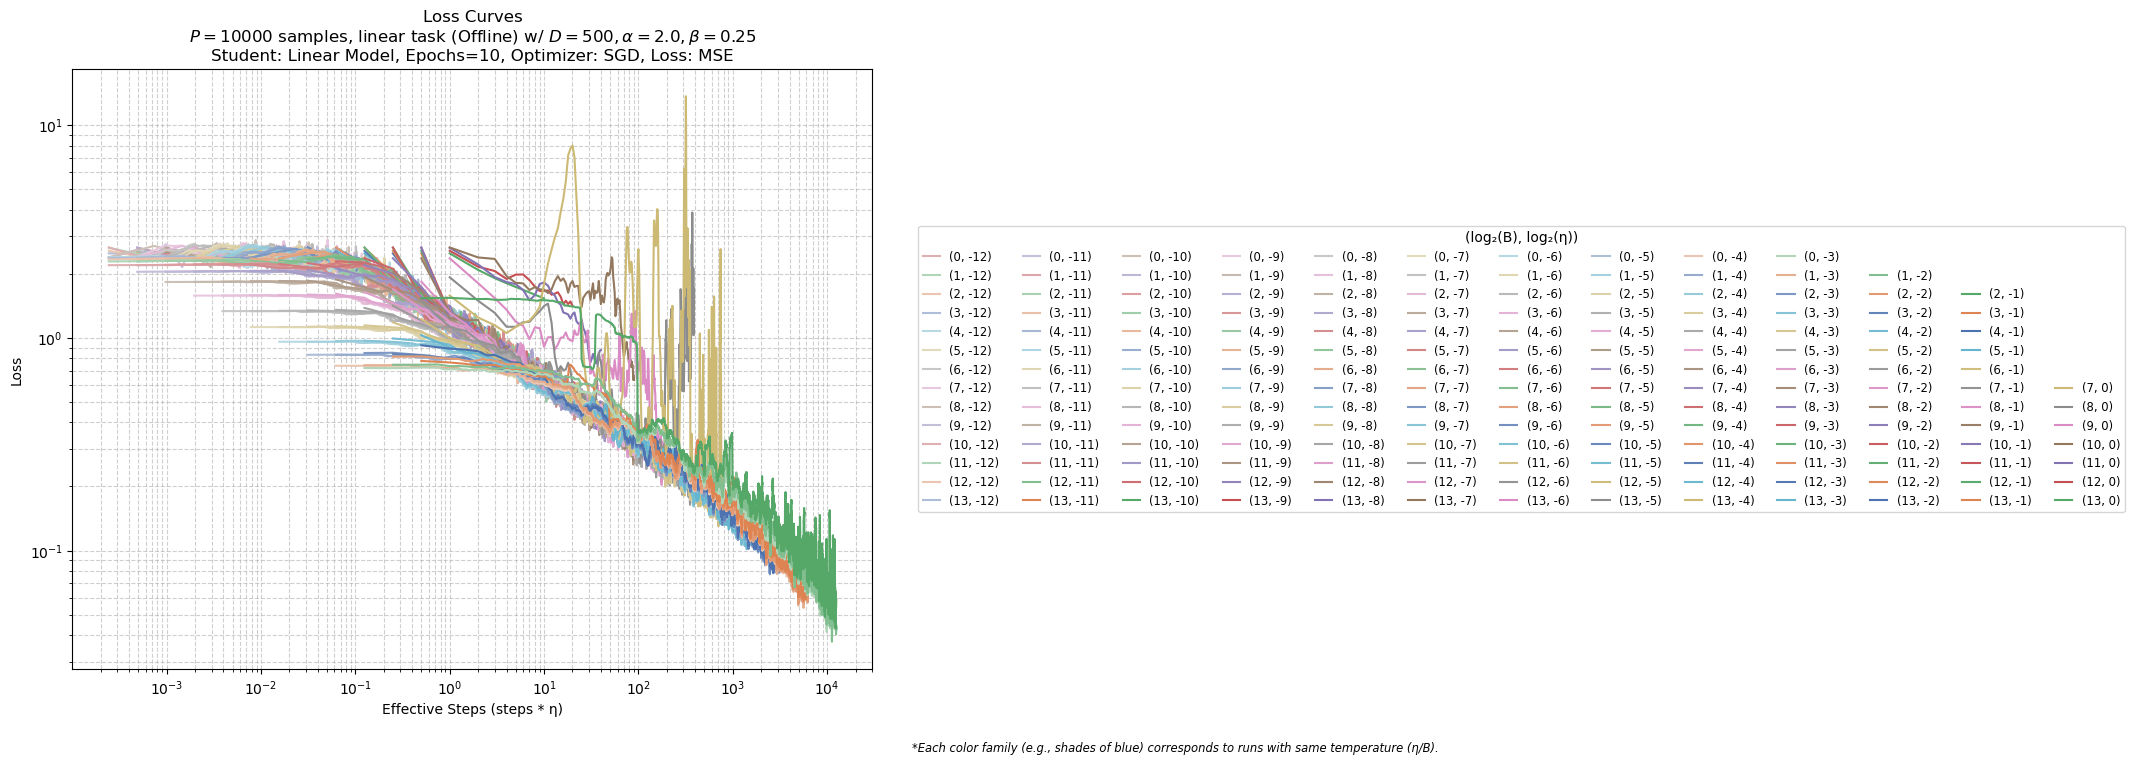

In [ ]:
plot_all_loss_curves(
    sample_aware_smooth_loss_dicts(loss_dict, rk_smoother),
    title_exp=experiment.plot_title(),
    use_eff_steps=True,
    x_scale="log",
)

In [ ]:
e_name = "offline_linear_teacher_alpha2p0_beta0p25_longest"
experiment = experiments[e_name]

loss_dict = loss_dicts[e_name]

In [ ]:
loss_dict = filter_loss_dict_by_loss_threshold(loss_dict, 100)

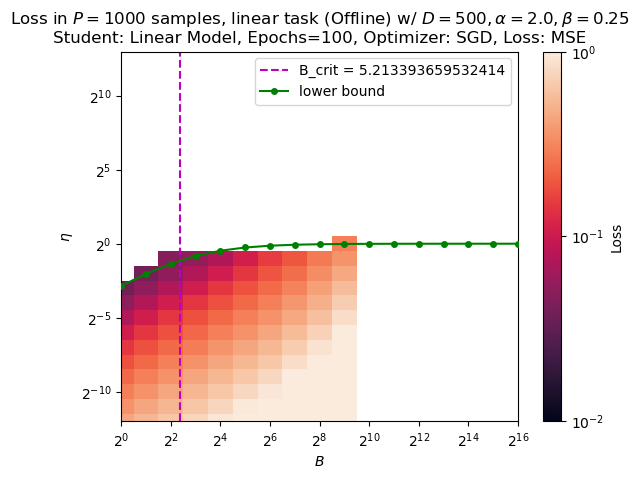

In [ ]:
plot_heatmap_with_theory_curve(
    sample_aware_smooth_loss_dicts(loss_dict, rk_smoother),
    # loss_dict,
    batch_sizes,
    etas,
    experiment.plot_title(),
    # first_divergence=first_divergence,
    lower_bound=lower_bound,
    # upper_bound=upper_bound,
    crit_batch=crit_batch,
    clim=(-2, 0),
);

(<Figure size 2170x800 with 1 Axes>,
 <Axes: title={'center': 'Loss Curves\n$P = 1000$ samples, linear task (Offline) w/ $D=500, \\alpha=2.0, \\beta=0.25$\nStudent: Linear Model, Epochs=100, Optimizer: SGD, Loss: MSE'}, xlabel='Effective Steps (steps * η)', ylabel='Loss'>)

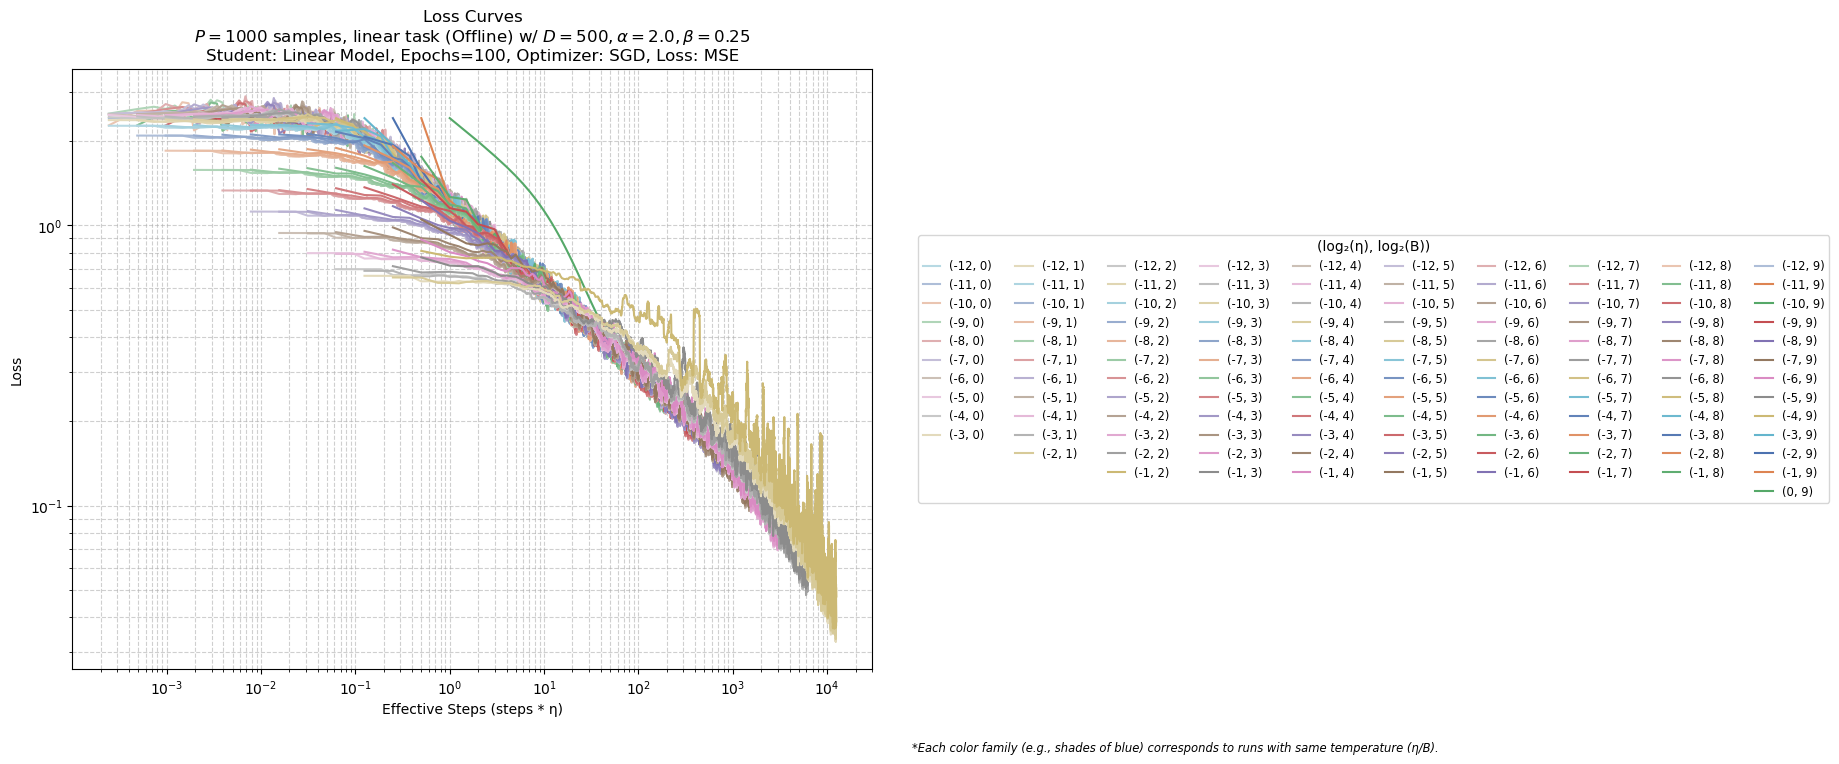

In [ ]:
plot_all_loss_curves(
    sample_aware_smooth_loss_dicts(loss_dict, rk_smoother),
    title_exp=experiment.plot_title(),
    use_eff_steps=True,
    x_scale="log",
)

In [ ]:
# import numpy as np
# from batch_size_studies.experiments import SyntheticExperimentLinearTeacher
# from batch_size_studies.definitions import LossType, OptimizerType
# from batch_size_studies.checkpoint_utils import load_experiment_weights
# from batch_size_studies.paths import EXPERIMENTS_DIR

# # --- 1. Define the *exact* same experiment config that you ran ---
# # This is crucial for finding the correct results file.
# # Make sure D, P, num_epochs, alpha, beta, etc., all match.
# experiment_config = SyntheticExperimentLinearTeacher(
#     D=500,
#     P=10000,
#     num_epochs=10,
#     alpha=2.0,
#     beta=0.25,
#     optimizer=OptimizerType.SGD,
#     loss_type=LossType.MSE,
# )

# # --- 2. Specify the batch size and eta for the specific run you're interested in ---
# batch_size_of_interest = 32
# eta_of_interest = 0.01

# # --- 3. Calculate the final training step ---
# # The runner saves a snapshot at the last step, which is total_steps - 1.
# steps_per_epoch = experiment_config.P // batch_size_of_interest
# total_steps = experiment_config.num_epochs * steps_per_epoch
# final_step = total_steps - 1

# print(f"Attempting to load weights for step: {final_step}")

# # --- 4. Load the weights from the final step ---
# # The function will automatically reconstruct the full weights from the saved data.
# final_weights = load_experiment_weights(
#     experiment=experiment_config,
#     batch_size=batch_size_of_interest,
#     eta=eta_of_interest,
#     step_to_load=final_step,
#     directory=EXPERIMENTS_DIR, # Or wherever you saved your experiments
# )

# # --- 5. Verify the result ---
# if final_weights is not None:
#     print("\nSuccessfully loaded final weights.")
#     print(f"Weight matrix shape: {final_weights.shape}")
#     # For a linear model, this should be (D, 1)
#     assert final_weights.shape == (experiment_config.D, 1)
#     print("First 5 weight values:")
#     print(final_weights[:5])
# else:
#     print("\nCould not find weights. Please check that:")
#     print("  - The experiment configuration matches the run exactly.")
#     print("  - The batch_size, eta, and calculated final_step are correct.")
#     print("  - The experiment completed successfully without diverging.")



In [ ]:
e_name = "offline_linear_teacher_alpha2p0_beta0p25_longest_fr"
experiment = experiments[e_name]

loss_dict = loss_dicts[e_name]

In [ ]:
loss_dict = filter_loss_dict_by_loss_threshold(loss_dict, 100)

In [ ]:
loss_dicts[e_name][RunKey(batch_size=1, eta=0.25)].keys()

dict_keys(['loss_history', 'epoch'])

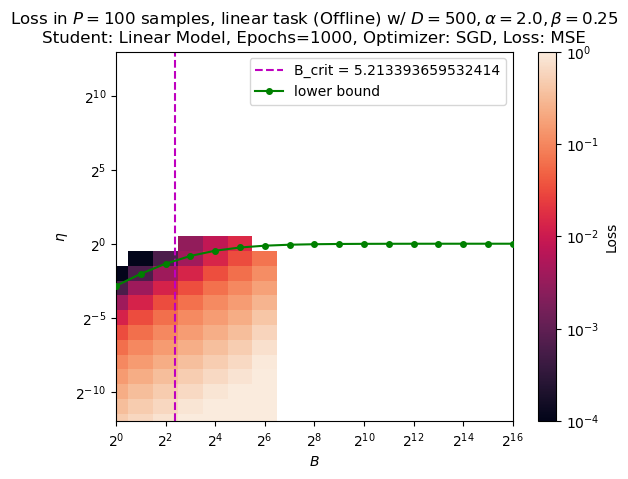

In [ ]:
plot_heatmap_with_theory_curve(
    sample_aware_smooth_loss_dicts(loss_dict, rk_smoother),
    # loss_dict,
    batch_sizes,
    etas,
    experiment.plot_title(),
    # first_divergence=first_divergence,
    lower_bound=lower_bound,
    # upper_bound=upper_bound,
    crit_batch=crit_batch,
    clim=(-4, 0),
);

(<Figure size 1810x800 with 1 Axes>,
 <Axes: title={'center': 'Loss Curves\n$P = 100$ samples, linear task (Offline) w/ $D=500, \\alpha=2.0, \\beta=0.25$\nStudent: Linear Model, Epochs=1000, Optimizer: SGD, Loss: MSE'}, xlabel='Effective Steps (steps * η)', ylabel='Loss'>)

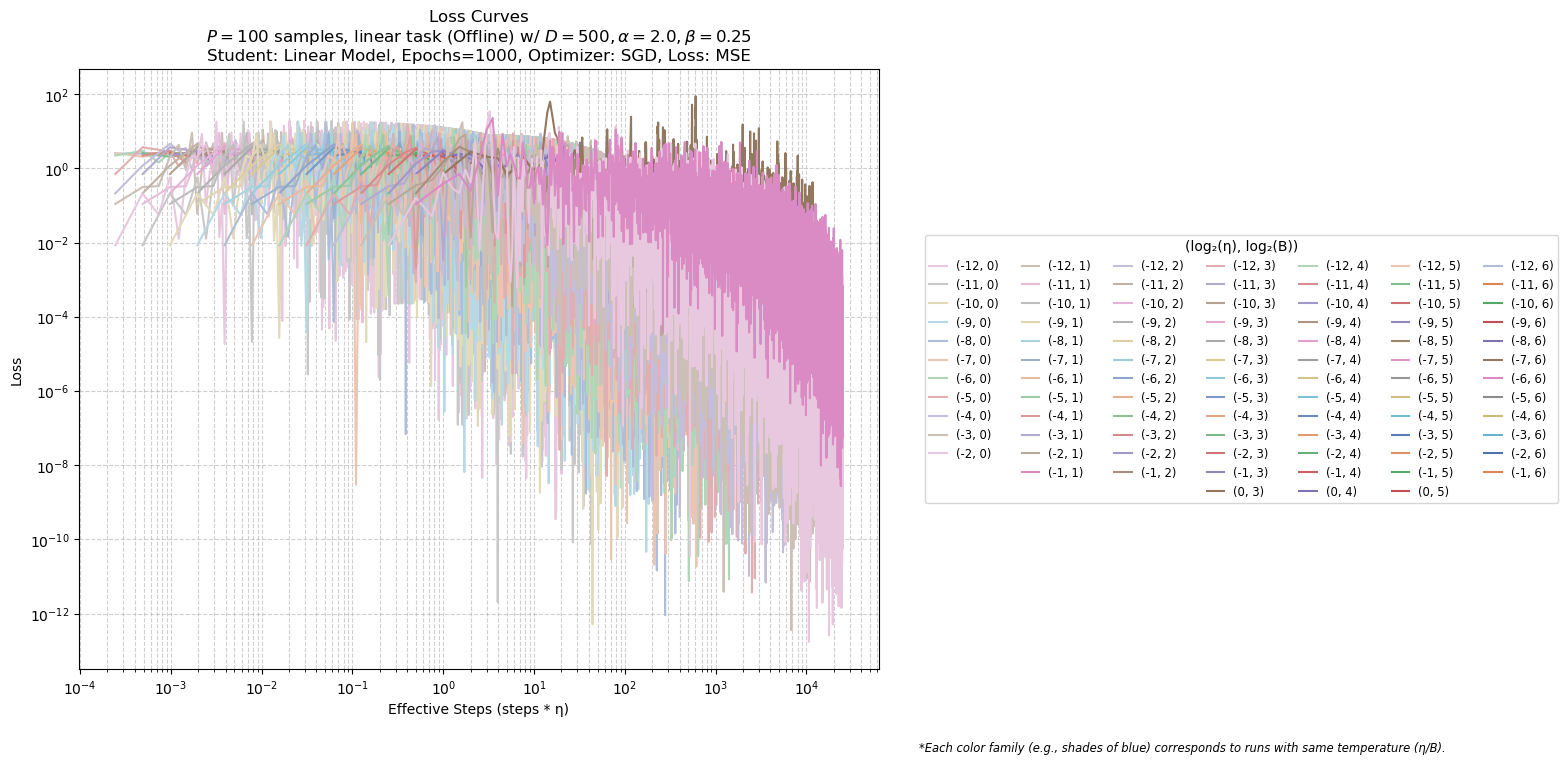

In [ ]:
plot_all_loss_curves(
    # sample_aware_smooth_loss_dicts(loss_dict, rk_smoother),
    loss_dict=loss_dict,
    title_exp=experiment.plot_title(),
    use_eff_steps=True,
    x_scale="log",
)